# Notebook 01 · Data Quality, Proxies, and Gap Characterization

**Pipeline position**: Phase A, Step 1 — runs after Notebook 00.

## Steps
1. **Sensor Loading** — Load the preprocessed sensor CSV from Notebook 00.
2. **Proxy Loading** — Load environmental proxies (e.g. temperature, radiation, humidity).
3. **Alignment** — Resample and synchronise multiple proxies onto the sensor index.
4. **Gap Characterization** — Classify missing data, diagnose missingness mechanism
   (MCAR / MAR / MNAR-power) using covariate correlation tests.
5. **Save** — Export the aligned dataset to `data/interim/aligned/`.

## Outputs
| Artifact | Path | Description |
|---|---|---|
| Aligned dataset | `data/interim/aligned/{station}_aligned_dataset.csv` | Sensor + proxy, resampled |
| Gap histogram   | `outputs/figures/01_01_{station}_gap_histogram.png`  | Gap-length distribution |
| Gap stats table | `outputs/tables/01_01_{station}_gap_stats.csv`       | Descriptive statistics |

In [1]:
import os
import pandas as pd
from IPython.display import display

from heritageshm.dataloader import load_preprocessed_sensor, load_proxy_data, save_interim_data
from heritageshm.preprocessing import align_multiple_proxies
from heritageshm.diagnostics import characterize_gaps
from heritageshm.viz import apply_theme

apply_theme(context='notebook')

## Step 1 · Load Preprocessed Sensor Data

### Parameter Tuning Guidance

| Parameter | Type | Description |
|---|---|---|
| `TARGET_STATION` | `str` | Station identifier matching the filename `{station}_preprocessed.csv` |

**Prerequisite**: Notebook 00 must have been run to generate the preprocessed sensor CSV.

In [2]:
TARGET_STATION = 'st02'

SENSOR_FILE = 'data/interim/sensor/%s_preprocessed.csv' % TARGET_STATION
df_sensor   = load_preprocessed_sensor(SENSOR_FILE)

print("Loaded %s sensor dataset: %s" % (TARGET_STATION, str(df_sensor.shape)))
print("Sensor date range: %s \u2192 %s" % (df_sensor.index.min(), df_sensor.index.max()))
df_sensor.head(3)

Loaded st02 sensor dataset: (116562, 5)
Sensor date range: 2018-07-25 23:40:00 → 2025-02-05 12:20:00


,charge,temp,hum,absinc_raw,absinc
datetime,,,,,
2018-07-25 23:40:00,3.49,21.750,45.115,2122.750,0.000
2018-07-26 00:00:00,3.47,21.555,45.155,2122.125,0.350
2018-07-26 00:20:00,3.47,21.365,45.040,2121.000,0.175


## Step 2 · Load Proxies

### Parameter Tuning Guidance

| Parameter | Type | Description |
|---|---|---|
| `PROXY_FILE` | `str` | Path to the environmental proxy CSV. Supported sources: ERA5, Oikolab, local station |
| `PROXY_COLS` | `list` | Columns to retain. Remove unused variables to reduce alignment overhead |
| `MAX_PROXY_MISSING_FRAC` | `float` | Post-alignment warning threshold. Any proxy column with a missing fraction above this triggers a warning (default `0.10` = 10 %) |

**Proxy selection for masonry / historic stone structures**:
- **Temperature** (`temperature`, `skin_temperature`, `urban_temperature`) — primary driver of thermal expansion.
- **Relative humidity** (`relative_humidity`, `dewpoint_temperature`, `wetbulb_temperature`) — co-primary for
  hygrothermal coupling in porous stone and historic masonry; do not omit.
- **Radiation** (`surface_solar_radiation`, `surface_thermal_radiation`) — critical for structures with
  significant thermal mass or direct solar exposure.
- **Wind** (`wind_speed`, `wind_direction`) — relevant for tall / slender elements.

Use cointegration tests in Notebook 02 to validate proxy selection quantitatively.

In [3]:
PROXY_FILE  = 'data/raw/proxies/oikolab_weather.csv'

# Peek at available columns without loading the full file
_sample = pd.read_csv(PROXY_FILE, nrows=0)
print("Available columns in proxy file:")
for c in _sample.columns:
    print("  -", c)

Available columns in proxy file:
  - datetime (UTC)
  - coordinates (lat,lon)
  - model (name)
  - model elevation (surface)
  - utc_offset (hrs)
  - temperature (degC)
  - dewpoint_temperature (degC)
  - relative_humidity (0-1)
  - wetbulb_temperature (degC)
  - skin_temperature (degC)
  - urban_temperature (degC)
  - wind_speed (m/s)
  - wind_direction (deg)
  - total_cloud_cover (0-1)
  - total_precipitation (mm of water equivalent)
  - surface_solar_radiation (W/m^2)
  - surface_thermal_radiation (W/m^2)


In [4]:
# === USER INPUT ===
PROXY_COLS = [
    'temperature (degC)',
    'dewpoint_temperature (degC)',
    'relative_humidity (0-1)',
    'wetbulb_temperature (degC)',
    'skin_temperature (degC)',
    'urban_temperature (degC)',
    # 'wind_speed (m/s)',
    # 'wind_direction (deg)',
    # 'total_cloud_cover (0-1)',
    # 'total_precipitation (mm of water equivalent)',
    'surface_solar_radiation (W/m^2)',
    'surface_thermal_radiation (W/m^2)',
]

# Maximum allowed missing fraction in any proxy column after alignment.
# Columns exceeding this trigger a warning (pipeline continues).
# Raise to 1.0 to suppress warnings; lower to 0.05 for stricter checking.
MAX_PROXY_MISSING_FRAC = 0.10
# ==================

META_COLS = [
    'coordinates (lat,lon)', 'model (name)',
    'model elevation (surface)', 'utc_offset (hrs)',
]

df_proxy = pd.read_csv(
    PROXY_FILE,
    parse_dates=['datetime (UTC)'],
    index_col='datetime (UTC)',
)
df_proxy.index.name = 'datetime'
df_proxy = df_proxy.drop(columns=[c for c in META_COLS if c in df_proxy.columns])
df_proxy = df_proxy[[c for c in PROXY_COLS if c in df_proxy.columns]]

print("Loaded proxy dataset: %s" % str(df_proxy.shape))
print("Proxy date range: %s \u2192 %s" % (df_proxy.index.min(), df_proxy.index.max()))
display(df_proxy.head(3))

proxies_dict = {'oikolab': df_proxy}
print("\nLoaded %d proxy dataset(s)." % len(proxies_dict))

Loaded proxy dataset: (72628, 8)
Proxy date range: 2018-01-01 00:00:00 → 2026-04-16 21:00:00


,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,
2018-01-01 00:00:00,7.15,5.91,0.92,6.28,6.29,7.14,0.0,320.89
2018-01-01 01:00:00,7.97,6.58,0.91,7.01,6.72,7.55,0.0,335.55
2018-01-01 02:00:00,7.89,6.05,0.88,6.67,7.42,7.54,0.0,336.98



Loaded 1 proxy dataset(s).


## Step 2b · Proxy Temporal Coverage Check

Verifies that the proxy data fully brackets the sensor monitoring period.
A silent temporal mismatch would silently produce NaN-filled proxy columns
in all downstream notebooks.

In [5]:
sensor_start, sensor_end = df_sensor.index.min(), df_sensor.index.max()
proxy_start,  proxy_end  = df_proxy.index.min(),  df_proxy.index.max()

coverage_ok = (proxy_start <= sensor_start) and (proxy_end >= sensor_end)

print("Sensor window : %s \u2192 %s" % (sensor_start, sensor_end))
print("Proxy window  : %s \u2192 %s" % (proxy_start,  proxy_end))

if coverage_ok:
    print("\u2713 Proxy data fully covers the sensor monitoring period.")
else:
    if proxy_start > sensor_start:
        print("\u26a0 WARNING: Proxy starts %s after sensor start. "
              "Sensor data before %s will have NaN proxies."
              % (proxy_start - sensor_start, proxy_start))
    if proxy_end < sensor_end:
        print("\u26a0 WARNING: Proxy ends %s before sensor end. "
              "Sensor data after %s will have NaN proxies."
              % (sensor_end - proxy_end, proxy_end))

assert coverage_ok, (
    "Proxy temporal coverage is insufficient. "
    "Extend the proxy extraction period to fully bracket the sensor "
    "monitoring window before proceeding."
)

Sensor window : 2018-07-25 23:40:00 → 2025-02-05 12:20:00
Proxy window  : 2018-01-01 00:00:00 → 2026-04-16 21:00:00
✓ Proxy data fully covers the sensor monitoring period.


## Step 3 · Resampling and Alignment

### Parameter Tuning Guidance

| Parameter | Type | Default | Description |
|---|---|---|---|
| `TARGET_FREQ` | `str` | `'h'` | Resampling frequency. `'h'` (hourly) suits most SHM applications. Use `'30min'`/`'15min'` for fast dynamics; `'2h'`/`'3h'` for slow thermal responses |

**Note**: `add_prefix=True` prepends the proxy source name to each column
(e.g. `oikolab_temperature (degC)`).  This prevents silent name collisions
if a second proxy source is added later.

In [8]:
TARGET_FREQ = 'h'  # Hourly — recommended default for masonry SHM

if proxies_dict:
    df_aligned = align_multiple_proxies(
        df_sensor,
        proxies_dict,
        resample_freq=TARGET_FREQ,
        add_prefix=False,   # prevents name collisions with multiple proxy sources
    )
else:
    print("No proxies loaded. Proceeding with sensor data only.")
    df_aligned = df_sensor.resample(TARGET_FREQ).mean()

print("Aligned dataset shape: %s" % str(df_aligned.shape))
df_aligned.head(3)

Resampling sensor data to h...
Complete index: 57278 time steps (2018-07-25 23:00:00 → 2025-02-05 12:00:00)
Sensor NaN rows (gaps): 17503
Resampling proxy 'oikolab' to h...
Merging 'oikolab'...
Final aligned dataset contains 57278 rows.
Aligned dataset shape: (57278, 13)


,charge,temp,hum,absinc_raw,absinc,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,,,,,,
2018-07-25 23:00:00,3.490000,21.750000,45.115000,2122.750000,0.000000,19.11,14.68,0.75,16.13,18.01,22.94,0.0,340.73
2018-07-26 00:00:00,3.473333,21.356667,44.898333,2121.333333,0.550000,18.76,14.93,0.78,16.15,17.32,22.55,0.0,338.83
2018-07-26 01:00:00,3.470000,20.861667,45.828333,2120.125000,1.816667,18.62,15.05,0.80,16.17,16.76,22.25,0.0,339.00


### Step 3b · Post-Alignment Missingness Audit

Inspects the missing-data fraction per column immediately after alignment.
Catches silent alignment failures (index mismatches, insufficient proxy coverage)
before they propagate to downstream notebooks.

Columns exceeding `MAX_PROXY_MISSING_FRAC` generate a warning.
Columns that are **entirely** NaN raise an error and stop the pipeline.

In [9]:
missing_frac           = df_aligned.isnull().mean().rename('missing_frac').to_frame()
missing_frac['pct']    = (missing_frac['missing_frac'] * 100).round(2)
missing_frac['n_miss'] = df_aligned.isnull().sum()

print("--- Post-Alignment Missingness Audit ---")
display(missing_frac.sort_values('missing_frac', ascending=False))

# Error: entirely-NaN columns indicate a total coverage failure
fully_missing = missing_frac[missing_frac['missing_frac'] == 1.0].index.tolist()
if fully_missing:
    raise ValueError(
        "The following columns are entirely NaN after alignment — "
        "check index compatibility and proxy coverage: %s" % fully_missing
    )

# Warning: partially-missing columns above the user-set threshold
high_missing = missing_frac[
    (missing_frac['missing_frac'] > MAX_PROXY_MISSING_FRAC) &
    (missing_frac['missing_frac'] < 1.0)
].index.tolist()
if high_missing:
    print("\n\u26a0 WARNING: The following columns exceed the %.0f%% missing threshold:"
          % (MAX_PROXY_MISSING_FRAC * 100))
    for col in high_missing:
        print("  %s — %.1f%% missing" % (col, missing_frac.loc[col, 'pct']))
    print("  Consider extending the proxy extraction period or removing these columns.")
else:
    print("\n\u2713 All columns are within the %.0f%% missing threshold."
          % (MAX_PROXY_MISSING_FRAC * 100))

--- Post-Alignment Missingness Audit ---


,missing_frac,pct,n_miss
charge,0.30558,30.56,17503
temp,0.30558,30.56,17503
hum,0.30558,30.56,17503
absinc_raw,0.30558,30.56,17503
absinc,0.30558,30.56,17503
temperature (degC),0.00000,0.00,0
dewpoint_temperature (degC),0.00000,0.00,0
relative_humidity (0-1),0.00000,0.00,0
wetbulb_temperature (degC),0.00000,0.00,0
skin_temperature (degC),0.00000,0.00,0



⚠ WARNING: The following columns exceed the 10% missing threshold:
  charge — 30.6% missing
  temp — 30.6% missing
  hum — 30.6% missing
  absinc_raw — 30.6% missing
  absinc — 30.6% missing
  Consider extending the proxy extraction period or removing these columns.


## Step 4 · Gap Characterization

Diagnoses gaps in the primary structural signal.  `characterize_gaps` now
performs a **missingness-covariate correlation test** to classify the
missingness mechanism:

| Mechanism | Meaning | Implication |
|---|---|---|
| **MCAR** | Gaps are random, independent of any variable | Standard interpolation adequate |
| **MAR** | Gaps correlated with an *observed* covariate | Regression-based imputation preferred |
| **MNAR-power** | Gaps correlated with `charge` == 0 | Power-outage events; proxy-based NeuralProphet imputation |

### Parameter Tuning Guidance

| Parameter | Type | Default | Description |
|---|---|---|---|
| `TARGET_COL` | `str` | `'absinc'` | Structural response column to analyse |
| `HISTOGRAM_BINS` | `int` | `50` | Number of bins in the gap-length histogram (20–100 typical) |
| `HISTOGRAM_COLOR` | `str` | `'black'` | Matplotlib colour for the histogram bars. Accepts named colours (`'black'`, `'steelblue'`) or hex codes (`'#2c3e50'`) |
| `max_impute_gap` | `int` | `0` | Max consecutive NaNs to fill by linear interpolation before classification. Keep at `0` unless you want a pre-scan with partial filling |


--- Gap Taxonomy for 'absinc' ---
Total Gaps Detected : 404
Average Gap Length  : 43.32 time steps
Maximum Gap Length  : 10501 time steps
Minimum Gap Length  : 1 time steps
Gap Length Std Dev  : 536.37 time steps

--- Missingness-Covariate Correlation Test ---
Covariate                                           |r|     p-value  Flag
---------------------------------------------------------------------------
charge                                              nan         nan  
temp                                                nan         nan  
hum                                                 nan         nan  
absinc_raw                                          nan         nan  
temperature (degC)                               0.1108  5.3146e-156  MAR candidate
dewpoint_temperature (degC)                      0.1288  2.8054e-210  MAR candidate
relative_humidity (0-1)                          0.0127  2.3775e-03  
wetbulb_temperature (degC)                       0.1244  3.7618e-196  

d:\Jupyter\neuralprophet\heritageshm\diagnostics.py:170: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])


Saved histogram to outputs/figures/01_01_st02_gap_histogram.png


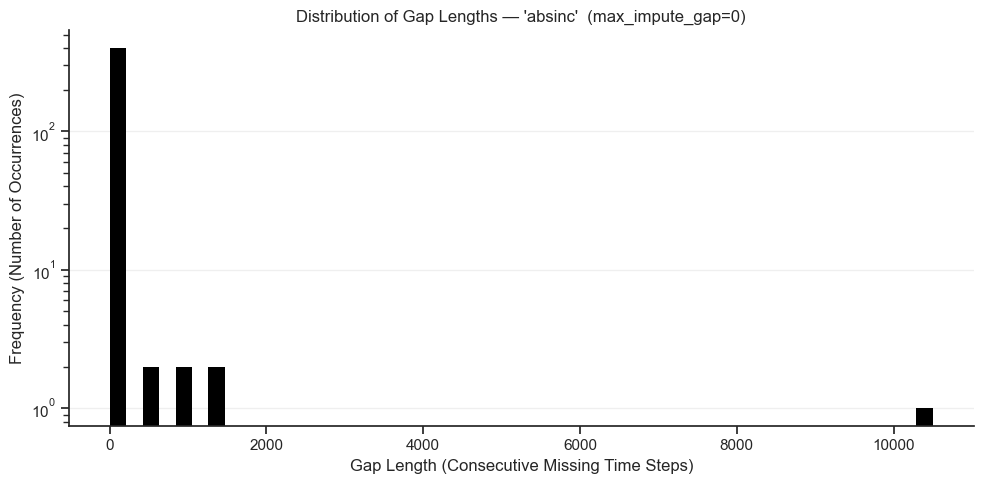

In [18]:
TARGET_COL       = 'absinc'   # Main structural response
HISTOGRAM_BINS   = 50         # Number of histogram bins
HISTOGRAM_COLOR  = 'black'    # Bar fill colour — change to e.g. '#2c7bb6' for blue

GAP_FIG_PATH  = 'outputs/figures/01_01_%s_gap_histogram.png'  % TARGET_STATION
GAP_TAB_PATH  = 'outputs/tables/01_01_%s_gap_stats.csv'       % TARGET_STATION
ALIGNED_PATH  = 'data/interim/aligned/%s_aligned_dataset.csv' % TARGET_STATION

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables',  exist_ok=True)
os.makedirs(os.path.dirname(ALIGNED_PATH), exist_ok=True)

gap_characterization_ok = False

try:
    df_aligned, gap_stats, gap_lengths = characterize_gaps(
        df_aligned,
        target_col=TARGET_COL,
        max_impute_gap=0,
        histogram_bins=HISTOGRAM_BINS,
        bar_color=HISTOGRAM_COLOR,
        save_plot_path=GAP_FIG_PATH,
    )
    gap_characterization_ok = True

except Exception as e:
    print("\u26a0 Gap characterization failed: %s" % e)
    print("The aligned dataset will NOT be saved. Resolve the error before proceeding.")

### Gap Statistics Summary

In [12]:
if gap_characterization_ok:
    total_obs     = len(df_aligned)
    total_missing = df_aligned[TARGET_COL].isnull().sum()
    missing_pct   = total_missing / total_obs * 100

    print("\n--- Gap Statistics for '%s' ---" % TARGET_COL)
    print("Total observations : %d"      % total_obs)
    print("Total missing      : %d (%.2f%%)" % (total_missing, missing_pct))
    display(gap_stats.rename('value').to_frame())

    gap_stats_export = gap_stats.rename('value').to_frame()
    gap_stats_export.loc['total_missing_pct'] = missing_pct
    gap_stats_export.to_csv(GAP_TAB_PATH)
    print("\nGap statistics saved to : " + GAP_TAB_PATH)
    print("Gap histogram saved to  : " + GAP_FIG_PATH)


--- Gap Statistics for 'absinc' ---
Total observations : 57278
Total missing      : 17503 (30.56%)


,value
count,404.000000
mean,43.324257
std,536.368699
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,10501.000000



Gap statistics saved to : outputs/tables/01_01_st02_gap_stats.csv
Gap histogram saved to  : outputs/figures/01_01_st02_gap_histogram.png


## Step 5 · Save Aligned Dataset

Saves only if gap characterization completed without errors.

In [13]:
if gap_characterization_ok:
    save_interim_data(df_aligned, ALIGNED_PATH)
    print("Aligned dataset saved to: " + ALIGNED_PATH)
else:
    print("Save skipped \u2014 gap characterization did not complete successfully.")

Interim data successfully saved to data/interim/aligned/st02_aligned_dataset.csv
Aligned dataset saved to: data/interim/aligned/st02_aligned_dataset.csv
